In [1]:
import logging
from itertools import combinations

import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import torch

from napistu_torch.load.foundation_models import FoundationModels
from napistu_torch.utils.tensor_utils import (
    compute_correlation_matrix
)
from napistu_torch.utils.torch_utils import (
    cleanup_tensors,
    ensure_device,
)
from napistu_torch.load.constants import ALL_MODEL_FULL_NAMES
from napistu_torch.utils.statistics import compare_top_k_union_ranks
from napistu_torch.utils.tensor_utils import compute_correlation_matrix
from napistu_torch.visualization.heatmaps import plot_heatmap
import matplotlib.pyplot as plt

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s:%(name)s:%(message)s')
logger = logging.getLogger(__name__)

# how to aggregate across layers
CONSENSUS_METHOD = "sum"
# select max absolute value for top-hits (True) or max raw value (False)
BY_ABSOLUTE_VALUE = False
VERBOSE = True
TOP_K = 10000
DEVICE = ensure_device(None, allow_autoselect=True)

OUTPUT_DIR = "output"
model_names = ALL_MODEL_FULL_NAMES #- {"scGPT"}


In [2]:
# load each model's weights, gene annotations, and model metadata
models = FoundationModels.load_multiple(OUTPUT_DIR, model_names)

INFO:napistu_torch.load.foundation_models:Loading weights (AIDOCell_aido_cell_3m_weights.npz) and metadata (  AIDOCell_aido_cell_3m_metadata.json) from output_dir (output)
INFO:napistu_torch.load.foundation_models:Successfully loaded all results
INFO:napistu_torch.load.foundation_models:Loading weights (scPRINT_medium_weights.npz) and metadata (  scPRINT_medium_metadata.json) from output_dir (output)
INFO:napistu_torch.load.foundation_models:Successfully loaded all results
INFO:napistu_torch.load.foundation_models:Loading weights (scPRINT_large_weights.npz) and metadata (  scPRINT_large_metadata.json) from output_dir (output)
INFO:napistu_torch.load.foundation_models:Successfully loaded all results
INFO:napistu_torch.load.foundation_models:Loading weights (scFoundation_weights.npz) and metadata (  scFoundation_metadata.json) from output_dir (output)
INFO:napistu_torch.load.foundation_models:Successfully loaded all results
INFO:napistu_torch.load.foundation_models:Loading weights (AIDOC

In [ ]:
# precalculate and cache operations that take more than a minute or so
results = dict()

# gene embedding correlations
results["gene_embedding_correlations"] = models.compare_embeddings()

## Compare embeddings

To assess whether the embeddings are organizing genes in a similar way, I directly compared them. Since their embedding dimensions differ I decided to generate a gene-gene distance matrix (using cosine distance) for each embedding and then I compared all pairs of distance matrices using Spearman correlation.

The highest concordance is between scGPT and scPRINT (rho ~ 0.28) while AIDO.Cell's gene embeddings show low concordance with the other models, and between the different AIDO.Cell models (i.e., the 3M, 10M, and 100M cell models). This may just be a feature of AIDO.Cell's architecture since it uses gene-level positional embeddings which may not actual learn gene-gene similarity.

In [3]:
comparisons = models.compare_embeddings()

print(f"\nFound {len(comparisons)} unique pairwise comparisons:")
for comparison, rho in comparisons.items():
    print(f"  {comparison}: {rho:.4f}")



Found 28 unique pairwise comparisons:
  AIDOCell_aido_cell_3m_vs_scPRINT_medium: 0.0253
  AIDOCell_aido_cell_3m_vs_scPRINT_large: -0.0004
  AIDOCell_aido_cell_3m_vs_scFoundation: 0.0005
  AIDOCell_aido_cell_3m_vs_AIDOCell_aido_cell_10m: 0.0025
  AIDOCell_aido_cell_3m_vs_scPRINT_small: 0.0004
  AIDOCell_aido_cell_3m_vs_AIDOCell_aido_cell_100m: 0.0006
  AIDOCell_aido_cell_3m_vs_scGPT: 0.0376
  scPRINT_medium_vs_scPRINT_large: 0.2671
  scPRINT_medium_vs_scFoundation: 0.0047
  scPRINT_medium_vs_AIDOCell_aido_cell_10m: 0.0192
  scPRINT_medium_vs_scPRINT_small: 0.2679
  scPRINT_medium_vs_AIDOCell_aido_cell_100m: 0.0047
  scPRINT_medium_vs_scGPT: 0.3727
  scPRINT_large_vs_scFoundation: 0.0004
  scPRINT_large_vs_AIDOCell_aido_cell_10m: 0.0003
  scPRINT_large_vs_scPRINT_small: 0.9774
  scPRINT_large_vs_AIDOCell_aido_cell_100m: 0.0004
  scPRINT_large_vs_scGPT: 0.0392
  scFoundation_vs_AIDOCell_aido_cell_10m: 0.0006
  scFoundation_vs_scPRINT_small: 0.0005
  scFoundation_vs_AIDOCell_aido_cell_100

## Compare attention

Next, I want to compare the gene-gene attention probabilities (the softmax, makes these a probability distribution for each column) to see how pairs of genes are attending to each other.

### Working with attention summaries

Since Foundation models all use Transformer-based architectural with multiple multi-headed attention layers we can summarize the attention mechanisms either layer-wise or as an aggregate over all layers.

#### From a single layers

At the level of an individual layer, a couple of useful summaries are:

- the raw attention patterns: (gene, gene)
- top-k attention pairs

In [4]:
A_MODEL = "scPRINT_small"
A_LAYER = 3
common_ids = models.get_common_identifiers()
fmodel = models.get_model(A_MODEL)

# calculate one layer's attention pattern
attention = fmodel.compute_reordered_attention(
    layer_idx = A_LAYER,
    target_ids = common_ids,
    apply_softmax = False,
)
print(attention.shape)

# pulling out its top-k attention pairs
top_k_attention_edges = fmodel.get_top_attentions(
    k = TOP_K,
    target_ids = common_ids,
    layer_indices = A_LAYER,
    apply_softmax = False,
    by_absolute_value = BY_ABSOLUTE_VALUE,
)

display(top_k_attention_edges.head())
cleanup_tensors(attention, top_k_attention_edges)


INFO:napistu_torch.load.foundation_models:Found 19002 identifiers (ontology: 'ensembl_gene') shared across 8 models


(19002, 19002)


,layer,from_idx,to_idx,from_gene,to_gene,attention
0,3,4865,18052,ENSG00000176387,ENSG00000153930,0.004903
1,3,15914,18052,ENSG00000163833,ENSG00000153930,0.004879
2,3,18047,18052,ENSG00000136944,ENSG00000153930,0.004812
3,3,2499,18052,ENSG00000198704,ENSG00000153930,0.004764
4,3,11911,18052,ENSG00000173409,ENSG00000153930,0.004685


Either of these summaries can be rolled up across layers but before doing so we can evaluate whether cross-layer summaries are loosly consistent.

To explore this I'll pull out the top-attention pairs for each layer and compare them across the layers within the same model.

For a single model this can be done with:

```python
# get top-k attention edges for each layer
top_k_attention_edges = (
    models.get_model(A_MODEL)
    .get_top_attentions(
        k = 10000,
        target_ids = common_ids,
        by_absolute_value = BY_ABSOLUTE_VALUE,
    )
)

# (gene x gene) summary as attention[arg-max(|attention|)]
(
    models.get_model(A_MODEL)
    .compute_consensus_attention(
        target_ids = common_ids,
        consensus_method = CONSENSUS_METHOD
    )
)
```

But, the `FoundationModels` class has convenience methods for aggregating summaries from multiple models.

Here, we'll use the `FoundationModels`'s `get_top_attentions()` to pull out each model x layer's top-K attention scores. A similar method, which will be used later, `get_max_attentions` can be used to create a 3D Tensor of each model's (gene x gene) consensus attention scores.


## Within model - across layers

### Looking at top attention pairs from each layer and model

1. define attention probabilities for each layer (I x I). Where is I is the length and ordering of `common_identifiers`
2. select the N greatest attention probabilities from each layer returning the row and column indices and the attention probability
3. aggregate across all layers and models and store results as a pd.DataFrame
4. rename row/column indices as ensembl genes using `common_identifiers`
5. for each model cound distinct row (from) and column (to) pairs
6. pivot so there is 1 row per from-to edge and columns represent counts of each pair in the top attentions of each model




In [5]:
# trial - testing max methods
#from napistu_torch.load.constants import VALID_FM_LAYER_CONSENSUS_METHODS

#attn_dict = dict()
#for consensus_method in VALID_FM_LAYER_CONSENSUS_METHODS:
#   attn_dict[consensus_method] = models.get_model(A_MODEL).compute_consensus_attention(target_ids = common_ids, consensus_method = consensus_method)

In [6]:
# only look at the common vocab to shrink the space from ~60K x 60K to ~20K x 20K
common_ids = models.get_common_identifiers()

model_layer_correlations = {}
model_layer_rank_agreement = {}
for model in models.models:

    model_name = model.full_name
    logger.info(f"Summarizing cross-layer attention consistency for {model_name}...")

    top_k_attention_edges = model.get_top_attentions(
        k = TOP_K,
        target_ids = common_ids,
        by_absolute_value = BY_ABSOLUTE_VALUE,
        verbose = VERBOSE
    )
    # re-extract the top-k edges across all layers
    distinct_top_edges = top_k_attention_edges[["from_gene", "to_gene"]].drop_duplicates()

    # extract the attention scores for the distinct top-k edges across all layers
    top_k_union = (
        model.get_specific_attentions(
            distinct_top_edges,
            target_ids = common_ids,
            compute_ranks = True,
            by_absolute_value = BY_ABSOLUTE_VALUE,
            verbose = VERBOSE
        )
    )

    wide_top_k_union = top_k_union.pivot(index = ["from_gene", "to_gene"], columns = "layer", values = "attention")

    corr, _ = compute_correlation_matrix(wide_top_k_union.to_numpy())
    model_layer_correlations[model_name] = corr

    model_layer_rank_agreement[model_name] = compare_top_k_union_ranks(
        top_k_union,
        grouping_vars = ["layer"],
        defining_vars = ["from_gene", "to_gene"],
        max_rank = len(common_ids) ** 2,
        top_k = TOP_K,
        rank_col = "attention_rank"
    )


INFO:napistu_torch.load.foundation_models:Found 19002 identifiers (ontology: 'ensembl_gene') shared across 8 models
INFO:__main__:Summarizing cross-layer attention consistency for AIDOCell_aido_cell_3m...
INFO:napistu_torch.load.foundation_models:Extracting top-10000 edges from layer 0 by raw value...
INFO:napistu_torch.load.foundation_models:Extracting top-10000 edges from layer 1 by raw value...
INFO:napistu_torch.load.foundation_models:Extracting top-10000 edges from layer 2 by raw value...
INFO:napistu_torch.load.foundation_models:Extracting top-10000 edges from layer 3 by raw value...
INFO:napistu_torch.load.foundation_models:Extracting top-10000 edges from layer 4 by raw value...
INFO:napistu_torch.load.foundation_models:Extracting top-10000 edges from layer 5 by raw value...
INFO:napistu_torch.load.foundation_models:Extracted 60000 total edges across 6 layers
INFO:napistu_torch.load.foundation_models:Extracting attentions from layer 0...
INFO:napistu_torch.load.foundation_models

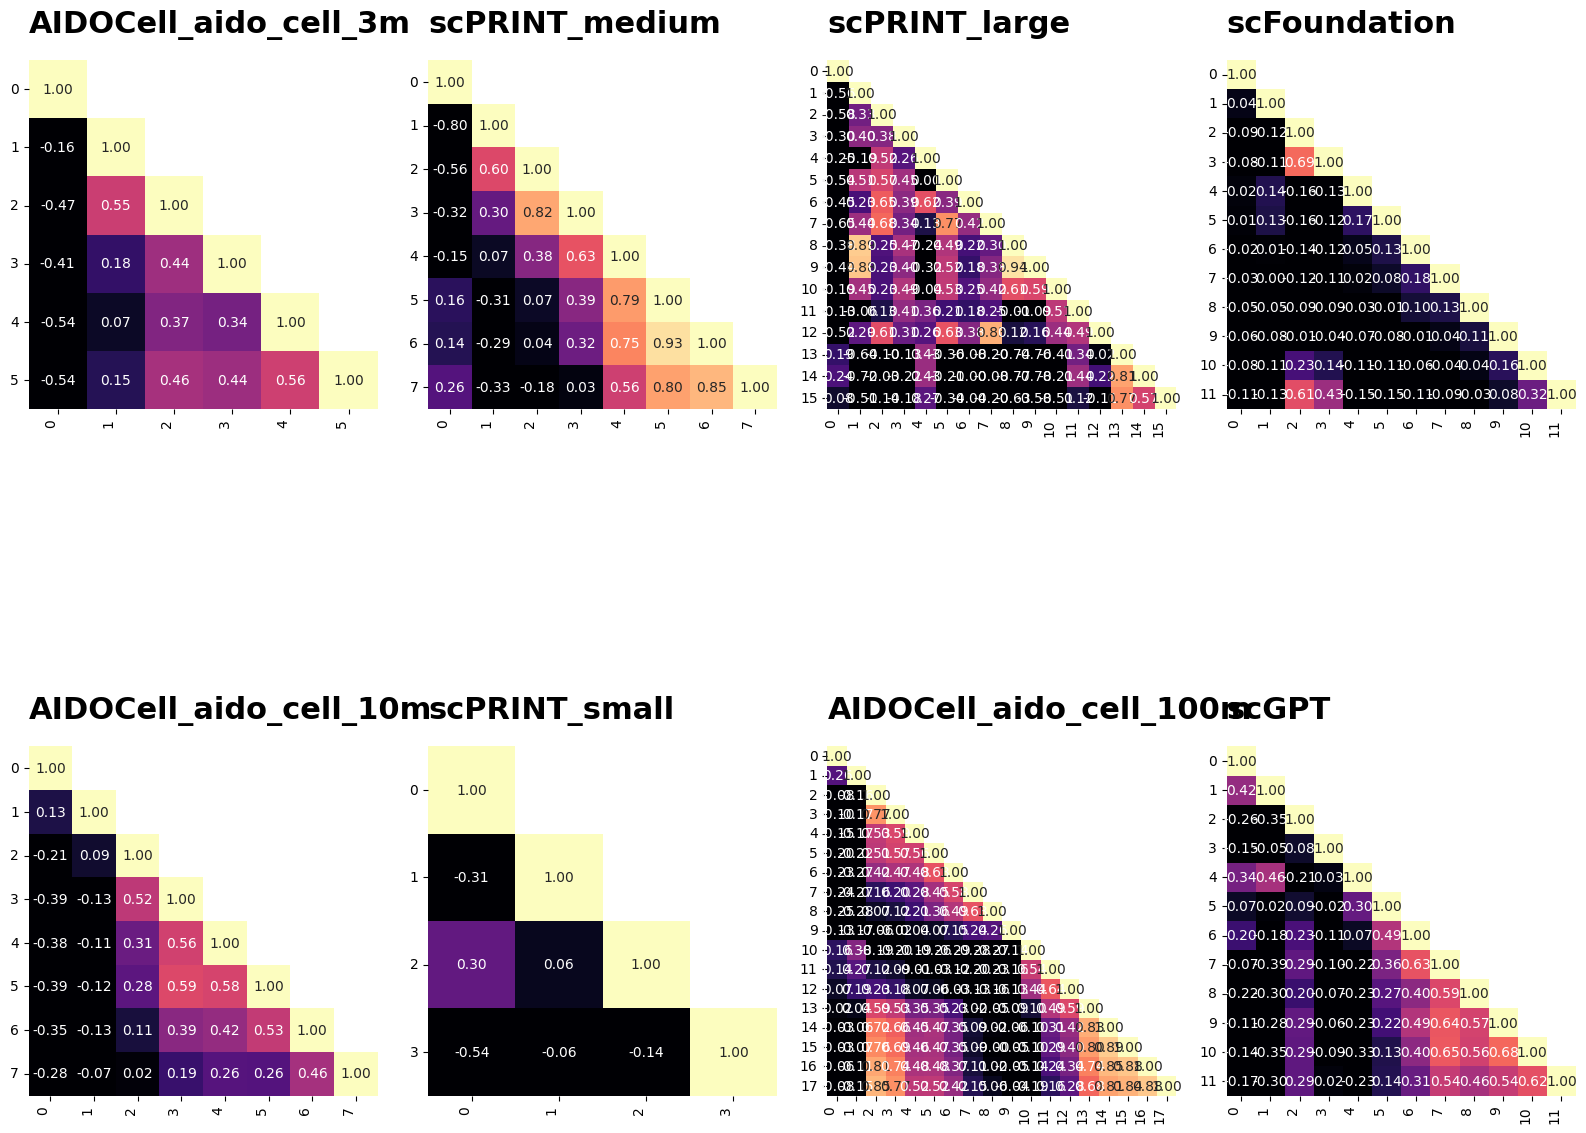

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(10, 20))
axes = axes.flatten()

for idx, model_name in enumerate(model_names):
    plot_heatmap(
        model_layer_correlations[model_name],
        row_labels = range(models.get_model(model_name).n_layers),
        title=model_name,
        cmap='magma',
        cbar=False,
        fmt='.2f',
        vmax=1,
        vmin=0,
        cbar_label='Spearman ρ',
        mask_upper_triangle=True,
        square=True,
        title_size=22,
        ax=axes[idx],
    )

plt.tight_layout()
plt.show()

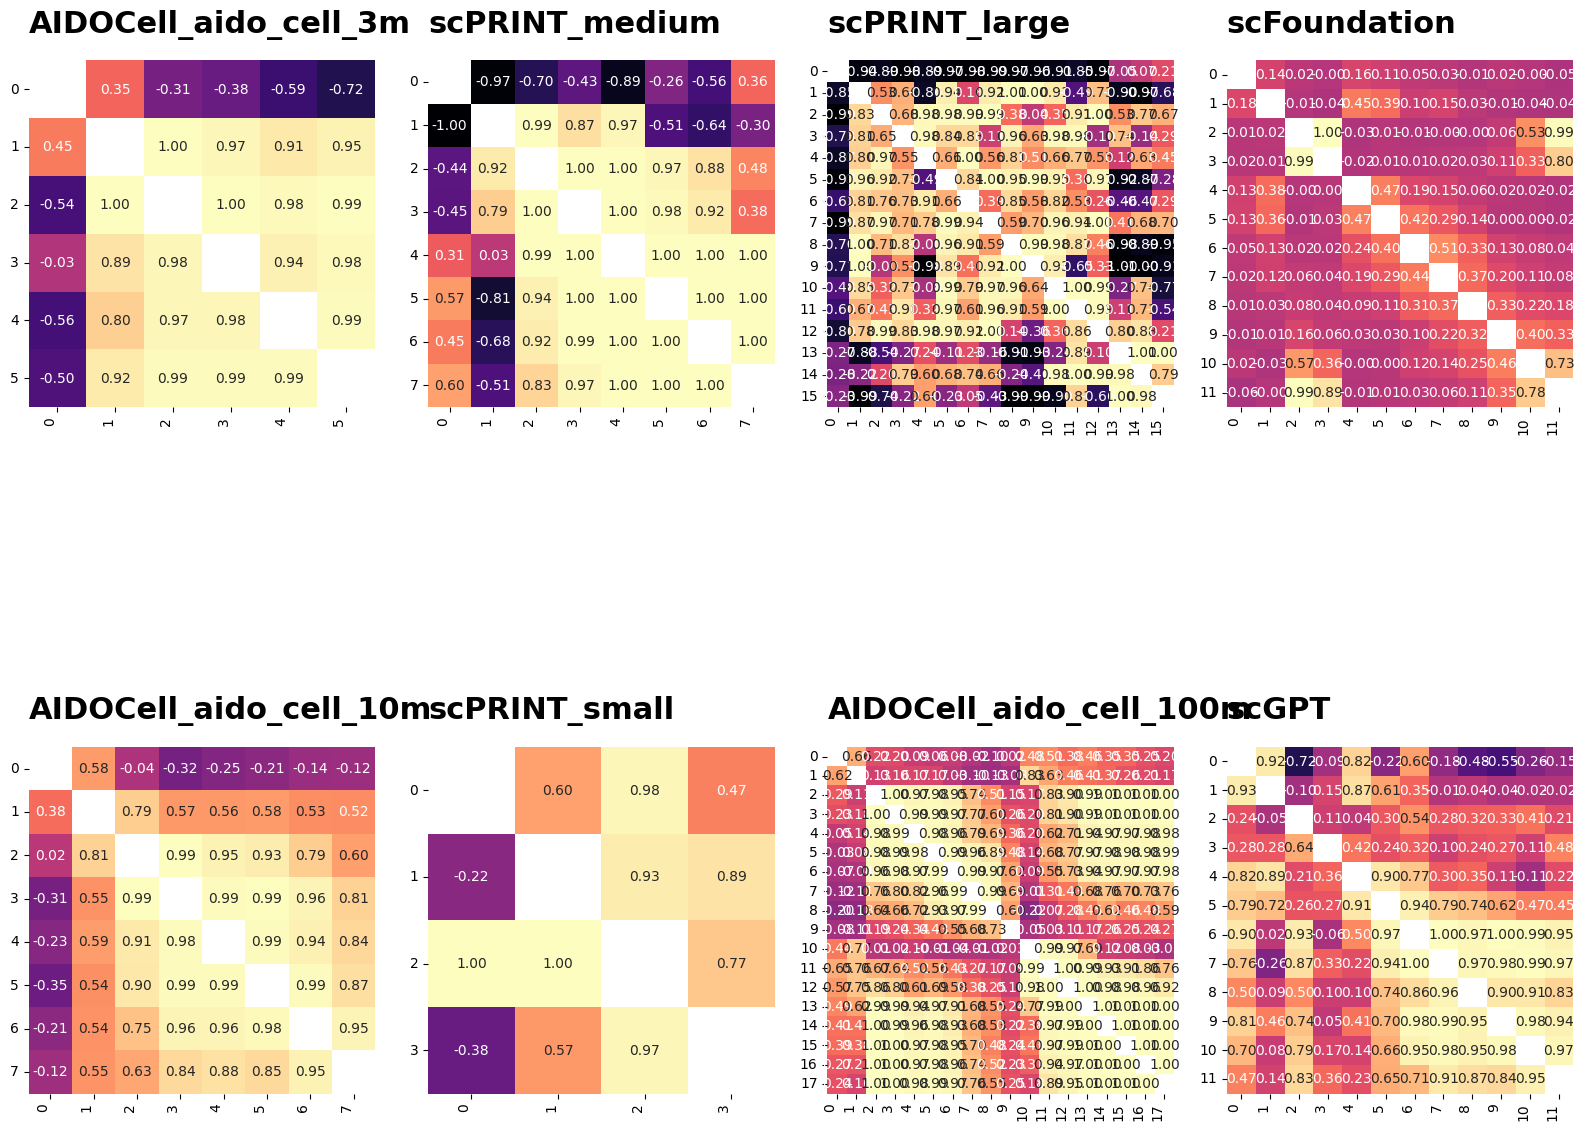

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(10, 20))
axes = axes.flatten()

for idx, model_name in enumerate(model_names):

    conditional_quantiles = (0.5 + -1 * model_layer_rank_agreement[model_name].pivot(index = "query_layer", columns = "eval_layer", values = "median_quantile"))*2

    plot_heatmap(
        conditional_quantiles,
        row_labels = range(models.get_model(model_name).n_layers),
        title=model_name,
        cmap='magma',
        cbar=False,
        fmt='.2f',
        vmax=1,
        vmin=-1,
        cbar_label='Spearman ρ',
        mask_upper_triangle=False,
        square=True,
        title_size=22,
        ax=axes[idx],
    )

plt.tight_layout()
plt.show()

## Across models (all layers)

In [9]:
cross_model_top_attentions = models.get_top_attentions(
    k = 1000,
    by_absolute_value = BY_ABSOLUTE_VALUE,
    reextract_union = True,
    compute_ranks = True
)

# look at the top attentions for each model/layer across all models and layers
wide_consistent_attentions = (
    cross_model_top_attentions.pivot(
        index = ["from_gene", "to_gene"],
        columns = ["model", "layer"],
        values = "attention"
    )
)

model_layer_labels = [f"{model}-{layer}" for model, layer in wide_consistent_attentions.columns]

cross_model_attention_corr, _ = compute_correlation_matrix(wide_consistent_attentions.to_numpy())


INFO:napistu_torch.load.foundation_models:Found 19002 identifiers (ontology: 'ensembl_gene') shared across 8 models
INFO:napistu_torch.load.foundation_models:Computing top-k attention for AIDOCell_aido_cell_3m...
INFO:napistu_torch.load.foundation_models:Computing top-k attention for scPRINT_medium...
INFO:napistu_torch.load.foundation_models:Computing top-k attention for scPRINT_large...
INFO:napistu_torch.load.foundation_models:Computing top-k attention for scFoundation...
INFO:napistu_torch.load.foundation_models:Computing top-k attention for AIDOCell_aido_cell_10m...
INFO:napistu_torch.load.foundation_models:Computing top-k attention for scPRINT_small...
INFO:napistu_torch.load.foundation_models:Computing top-k attention for AIDOCell_aido_cell_100m...
INFO:napistu_torch.load.foundation_models:Computing top-k attention for scGPT...
INFO:napistu_torch.load.foundation_models:Re-extracting top edges from every model and layer...


### layer x layer attention correlation

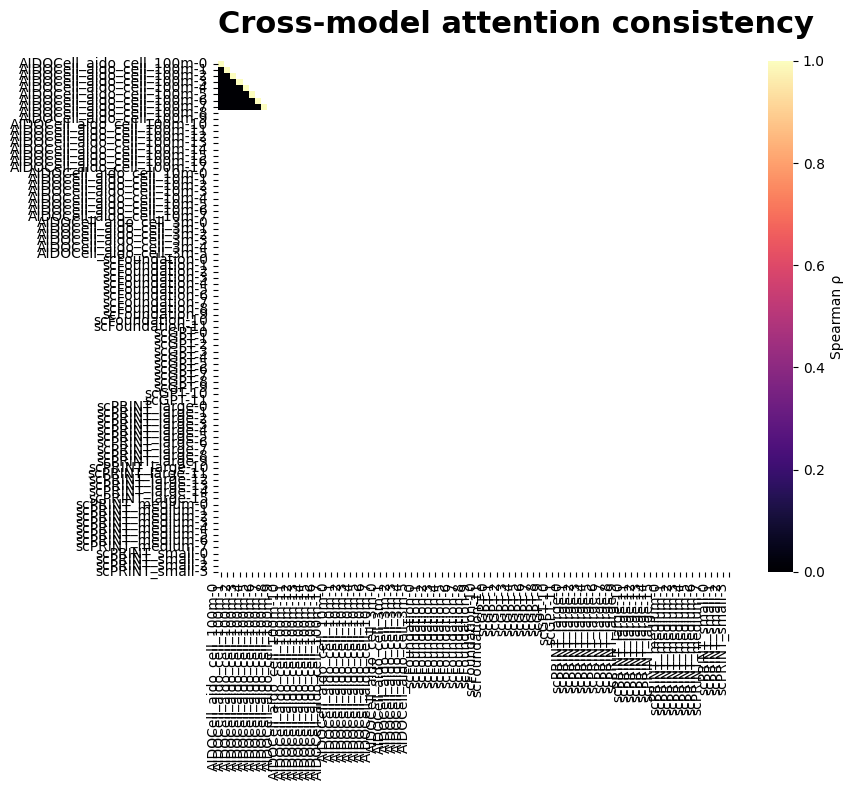

In [20]:
plot_heatmap(
    cross_model_attention_corr,
    row_labels = model_layer_labels,
    title="Cross-model attention consistency",
    cmap='magma',
    cbar=True,
    fmt='.2f',
    vmax=1,
    vmin=0,
    cbar_label='Spearman ρ',
    mask_upper_triangle=True,
    annot=False,
    square=True,
    title_size=22,
)

plt.show()

In [11]:
model_layer_labels_df = pd.DataFrame(
    wide_consistent_attentions.columns.tolist(),
    columns = ["model", "layer"]
)
model_layer_labels_df["label"] = model_layer_labels

triplet_df = (
    pd.DataFrame(
        cross_model_attention_corr,
        index = model_layer_labels,
        columns = model_layer_labels
    )
    .stack()
    .reset_index(name='value')
    .rename(columns={'level_0': 'row', 'level_1': 'col'})
    .query('row > col')  # Lower triangle excluding diagonal
    # expand layer metadata
    .merge(model_layer_labels_df.rename(columns = {"model" : "model1", "layer" : "layer1", "label" : "row"}))
    .merge(model_layer_labels_df.rename(columns = {"model" : "model2", "layer" : "layer2", "label" : "col"}))
)

triplet_df.query('model1 != model2').sort_values('value', ascending = True).head(10)

,row,col,value,model1,layer1,model2,layer2
2431,scPRINT_small-0,scPRINT_large-4,-0.435871,scPRINT_small,0,scPRINT_large,4
2441,scPRINT_small-0,scPRINT_large-14,-0.432866,scPRINT_small,0,scPRINT_large,14
2592,scPRINT_small-2,scPRINT_large-4,-0.417994,scPRINT_small,2,scPRINT_large,4
2440,scPRINT_small-0,scPRINT_large-13,-0.348268,scPRINT_small,0,scPRINT_large,13
2599,scPRINT_small-2,scPRINT_large-11,-0.310293,scPRINT_small,2,scPRINT_large,11
2438,scPRINT_small-0,scPRINT_large-11,-0.310120,scPRINT_small,0,scPRINT_large,11
260,scPRINT_medium-1,scPRINT_large-10,-0.268754,scPRINT_medium,1,scPRINT_large,10
2602,scPRINT_small-2,scPRINT_large-14,-0.255542,scPRINT_small,2,scPRINT_large,14
2601,scPRINT_small-2,scPRINT_large-13,-0.217978,scPRINT_small,2,scPRINT_large,13
259,scPRINT_medium-1,scPRINT_large-9,-0.211970,scPRINT_medium,1,scPRINT_large,9


### Layer x layer rank consistency 

In [12]:
model_x_layer_rank_agreement = compare_top_k_union_ranks(
    cross_model_top_attentions,
    grouping_vars = ["model", "layer"],
    defining_vars = ["from_gene", "to_gene"],
    max_rank = len(common_ids) ** 2,
    top_k = TOP_K,
    rank_col = "attention_rank"
)

# [0,1] low quantiles are more consistent (ranks in attent B | top in A)
raw_conditional_quantiles = (
    model_x_layer_rank_agreement
    .pivot(
        index = ["query_model", "query_layer"],
        columns = ["eval_model", "eval_layer"],
        values = "median_quantile"
    )
    .sort_index(axis=1, level=[0, 1])
)

# [0,1] -> [-1,1] with values near 1 being more consistent
conditional_quantiles = (0.5 + -1 * raw_conditional_quantiles)*2

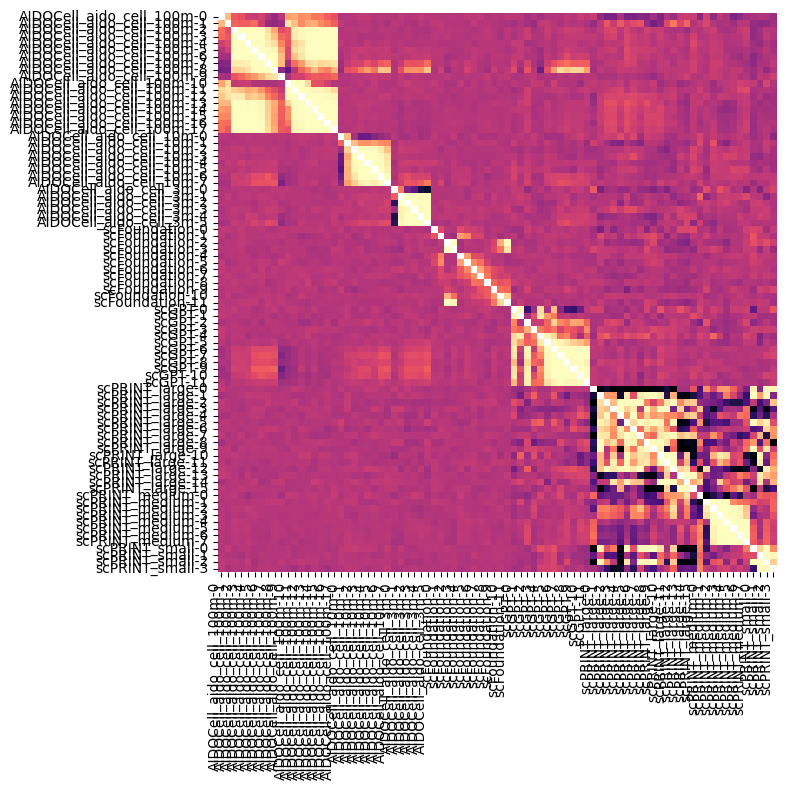

In [13]:
model_layer_labels = [f"{model}-{layer}" for model, layer in conditional_quantiles.columns]

plot_heatmap(
    conditional_quantiles,
    row_labels = model_layer_labels,
    cmap='magma',
    cbar=False,
    fmt='.2f',
    vmax=1,
    vmin=-1,
    cbar_label='Spearman ρ',
    mask_upper_triangle=False,
    annot=False,
    square=True,
    title_size=22,
)

plt.show()

In [14]:
model_x_layer_rank_agreement.query('query_model != eval_model').sort_values('median_quantile', ascending = True).groupby(['eval_model', 'query_model']).first()

query_layer  eval_layer  \
eval_model              query_model                                        
AIDOCell_aido_cell_100m AIDOCell_aido_cell_10m             6           7   
                        AIDOCell_aido_cell_3m              5           7   
                        scFoundation                       8          13   
                        scGPT                              9           8   
                        scPRINT_large                     14          14   
                        scPRINT_medium                     0          17   
                        scPRINT_small                      2           4   
AIDOCell_aido_cell_10m  AIDOCell_aido_cell_100m            8           6   
                        AIDOCell_aido_cell_3m              5           7   
                        scFoundation                       9           0   
                        scGPT                              9           7   
                        scPRINT_large                      5           0   
                        scPRINT_medium                     0           4   
                        scPRINT_small                      0           7   
AIDOCell_aido_cell_3m   AIDOCell_aido_cell_100m            8           5   
                        AIDOCell_aido_cell_10m             7           5   
                        scFoundation                       6           1   
                        scGPT                              9           5   
                        scPRINT_large                      5           5   
                        scPRINT_medium                     0           3   
                        scPRINT_small                      2           1   
scFoundation            AIDOCell_aido_cell_100m            8           5   
                        AIDOCell_aido_cell_10m             7           1   
                        AIDOCell_aido_cell_3m              3          11   
                        scGPT                             10           5   
                        scPRINT_large                      9           8   
                        scPRINT_medium                     0           4   
                        scPRINT_small                      1           6   
scGPT                   AIDOCell_aido_cell_100m            8           7   
                        AIDOCell_aido_cell_10m             7           7   
                        AIDOCell_aido_cell_3m              5           8   
                        scFoundation                       9           2   
                        scPRINT_large                      5           4   
                        scPRINT_medium                     6           2   
                        scPRINT_small                      0           6   
scPRINT_large           AIDOCell_aido_cell_100m            1          12   
                        AIDOCell_aido_cell_10m             3           6   
                        AIDOCell_aido_cell_3m              0           0   
                        scFoundation                       1           9   
                        scGPT                              4           2   
                        scPRINT_medium                     0          14   
                        scPRINT_small                      0           9   
scPRINT_medium          AIDOCell_aido_cell_100m           11           7   
                        AIDOCell_aido_cell_10m             1           2   
                        AIDOCell_aido_cell_3m              1           0   
                        scFoundation                       9           1   
                        scGPT                              4           2   
                        scPRINT_large                     10           3   
                        scPRINT_small                      3           0   
scPRINT_small           AIDOCell_aido_cell_100m           10           2   
                        AIDOCell_aido_cell_10m             1           2   
                     

## Across models (comparing cross-layer model consensus attentions)

In [15]:
consensus_top_k = models.get_consensus_top_attentions(
    k = TOP_K,
    consensus_method = CONSENSUS_METHOD,
    by_absolute_value = BY_ABSOLUTE_VALUE,
    reextract_union = True,
    compute_ranks = True
)

INFO:napistu_torch.load.foundation_models:Found 19002 identifiers (ontology: 'ensembl_gene') shared across 8 models
INFO:napistu_torch.load.foundation_models:Computing consensus attention for AIDOCell_aido_cell_3m...
INFO:napistu_torch.load.foundation_models:Computing consensus attention for scPRINT_medium...
INFO:napistu_torch.load.foundation_models:Computing consensus attention for scPRINT_large...
INFO:napistu_torch.load.foundation_models:Computing consensus attention for scFoundation...
INFO:napistu_torch.load.foundation_models:Computing consensus attention for AIDOCell_aido_cell_10m...
INFO:napistu_torch.load.foundation_models:Computing consensus attention for scPRINT_small...
INFO:napistu_torch.load.foundation_models:Computing consensus attention for AIDOCell_aido_cell_100m...
INFO:napistu_torch.load.foundation_models:Computing consensus attention for scGPT...


In [16]:
consensus_top_k

,from_gene,to_gene,attention,attention_rank,model
0,ENSG00000168779,ENSG00000198033,12.120096,1,AIDOCell_aido_cell_3m
1,ENSG00000189091,ENSG00000242120,11.512592,2,AIDOCell_aido_cell_3m
2,ENSG00000189091,ENSG00000158748,11.362871,3,AIDOCell_aido_cell_3m
3,ENSG00000168779,ENSG00000158748,11.013711,4,AIDOCell_aido_cell_3m
4,ENSG00000177182,ENSG00000177182,10.992044,5,AIDOCell_aido_cell_3m
...,...,...,...,...,...
639779,ENSG00000110958,ENSG00000197444,18.371775,9996,scGPT
639780,ENSG00000166479,ENSG00000005075,18.371565,9997,scGPT
639781,ENSG00000135406,ENSG00000122691,18.371368,9998,scGPT
639782,ENSG00000236125,ENSG00000013306,18.371363,9999,scGPT


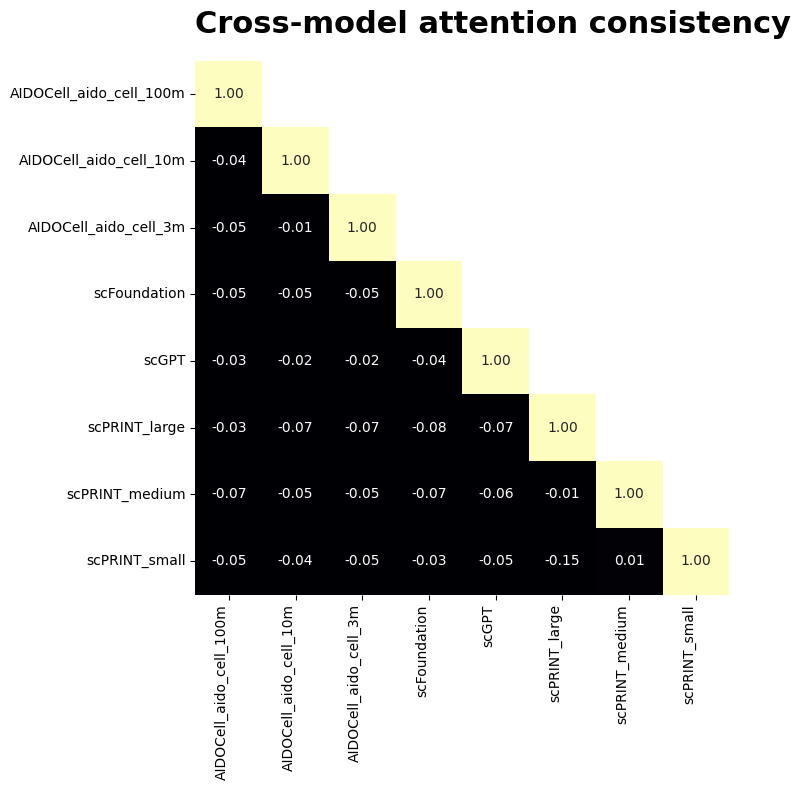

In [17]:
wide_consensus_top_k = consensus_top_k.pivot(index = ["from_gene", "to_gene"], columns = "model", values = "attention")

cross_model_attention_corr, _ = compute_correlation_matrix(wide_consensus_top_k.to_numpy())

plot_heatmap(
    cross_model_attention_corr,
    row_labels = wide_consensus_top_k.columns,
    title="Cross-model attention consistency",
    cmap='magma',
    cbar=False,
    fmt='.2f',
    vmax=1,
    vmin=0,
    cbar_label='Spearman ρ',
    mask_upper_triangle=True,
    annot=True,
    square=True,
    title_size=22,
)

plt.show()

In [18]:
model_x_layer_rank_agreement = compare_top_k_union_ranks(
    consensus_top_k,
    grouping_vars = ["model"],
    defining_vars = ["from_gene", "to_gene"],
    max_rank = len(common_ids) ** 2,
    top_k = TOP_K,
    rank_col = "attention_rank"
)

# [0,1] low quantiles are more consistent (ranks in attent B | top in A)
raw_conditional_quantiles = (
    model_x_layer_rank_agreement
    .pivot(
        index = ["query_model"],
        columns = ["eval_model"],
        values = "median_quantile"
    )
    .sort_index(axis=1, level=[0, 1])
)

# [0,1] -> [-1,1] with values near 1 being more consistent
conditional_quantiles = (0.5 + -1 * raw_conditional_quantiles)*2

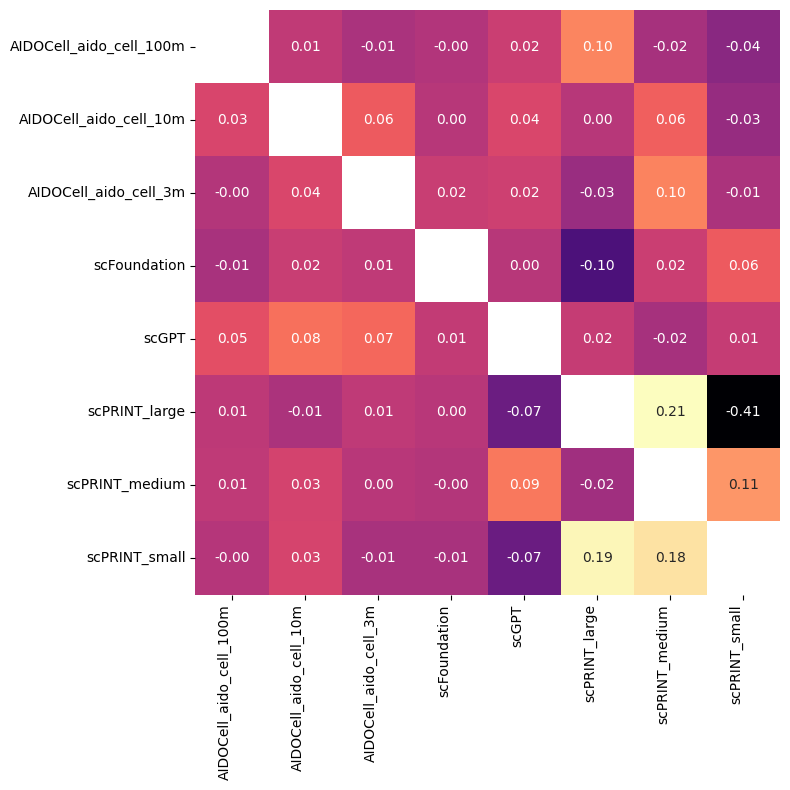

In [19]:
plot_heatmap(
    conditional_quantiles,
    row_labels = raw_conditional_quantiles.columns,
    cmap='magma',
    cbar=False,
    fmt='.2f',
    vmax=0.2,
    vmin=-0.2,
    cbar_label='Spearman ρ',
    mask_upper_triangle=False,
    annot=True,
    square=True,
    title_size=22,
)

plt.show()